# Generalized Linear Mixed Effects Models in R

## Overview

Generalized linear mixed effects models (GLMMs) combine the flexibility of GLMs (non-normal response distributions) with the random effects structure of LMMs (non-independent observations). Use them when your response is binary, a count, or otherwise non-normal AND your observations are clustered or repeated.

| Response Type | Family | Link |
|---|---|---|
| Binary (0/1) | `binomial` | `logit` |
| Proportion (0-1) | `binomial` | `logit` |
| Count (non-negative integer) | `poisson` | `log` |
| Overdispersed count | `nbinom2` (glmmTMB) | `log` |
| Continuous, right-skewed | `Gamma` | `log` |

## Applications by Sector

| Sector | Example |
|---|---|
| **Ecology** | Species presence/absence at sites surveyed repeatedly across years (binomial + site random effect); invertebrate counts per sample nested within sites (NB + site random effect) |
| **Healthcare** | Patient readmission (yes/no) across hospitals (binomial + hospital random effect); adverse event counts across repeated visits (Poisson + patient random effect) |
| **Finance** | Loan default (yes/no) across branches (binomial + branch random effect); fraud counts per account over time (Poisson + account random effect) |
| **Insurance** | Claim filing (yes/no) within agent portfolios (binomial + agent random effect); annual claim counts per policyholder over years (Poisson + policyholder random effect) |

---

## Assumptions Checklist

- [ ] **Correct distribution family:** Response matches the chosen GLM family
- [ ] **Correct link function:** Log-linearity for Poisson/NB; logit-linearity for binomial
- [ ] **Conditional independence:** Observations are independent after accounting for random effects
- [ ] **Normality of random effects:** Group-level deviations are approximately normally distributed
- [ ] **No overdispersion for Poisson:** Variance approximately equals mean — always test with DHARMa
- [ ] **Adequate group sizes:** Enough observations per group to estimate random effects reliably

> Standard diagnostic plots are not interpretable for GLMMs. Always use DHARMa — see `dharma_diagnostics.ipynb`.

---

## Setup

In [1]:
library(tidyverse)
library(ggplot2)
library(lme4)         # glmer() — binomial and Poisson GLMMs
library(glmmTMB)      # preferred for NB, zero-inflated, and Gamma GLMMs
library(DHARMa)       # simulation-based diagnostics — essential
library(broom.mixed)  # tidy model output
library(performance)  # r2()
library(ggeffects)    # marginal effects plots

set.seed(42)

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'lme4' was built under R version 4.4.3"
Loading required package: Matrix


Attaching package: 'Matrix'


Th

## Data

We simulate two datasets designed to mirror real ecological and industry use cases:
1. **Species detection** — presence/absence across sites surveyed repeatedly over years (binomial GLMM)
2. **Invertebrate counts** — counts per sample, samples nested within sites (negative binomial GLMM)

In [2]:
n_sites  <- 20; n_visits <- 5; N <- n_sites * n_visits
site_re  <- rnorm(n_sites, 0, 1)

# ── Binary: species detection ─────────────────────────────────────────────────
detection_data <- tibble(
  site        = rep(paste0("site", 1:n_sites), each = n_visits),
  year        = rep(2018:2022, times = n_sites),
  temperature = rnorm(N, 15, 3),
  log_odds    = -1 + 0.15 * temperature + rep(site_re, each = n_visits),
  detected    = rbinom(N, 1, plogis(log_odds))
) %>% select(-log_odds)

# ── Count: invertebrate abundance ────────────────────────────────────────────
n_samples <- 4; N2 <- n_sites * n_samples
site_re2  <- rnorm(n_sites, 0, 0.6)

count_data <- tibble(
  site  = rep(paste0("site", 1:n_sites), each = n_samples),
  pH    = rnorm(N2, 7.5, 0.8),
  mu    = exp(1.5 + 0.3 * pH + rep(site_re2, each = n_samples)),
  count = MASS::rnegbin(N2, mu = mu, theta = 2)
) %>% select(-mu)

cat(sprintf("Detection: N=%d, rate=%.1f%%\n", N, mean(detection_data$detected)*100))
cat(sprintf("Counts:    N=%d, mean=%.1f, var=%.1f\n",
            N2, mean(count_data$count), var(count_data$count)))

Detection: N=100, rate=76.0%
Counts:    N=80, mean=40.8, var=1482.0


---

## Binomial GLMM

**Question:** Does temperature predict species detection probability, accounting for non-independence of repeated visits within sites?

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: detected ~ temperature + (1 | site)
   Data: detection_data

      AIC       BIC    logLik -2*log(L)  df.resid 
    106.2     114.0     -50.1     100.2        97 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.2266  0.1611  0.3204  0.4553  1.2713 

Random effects:
 Groups Name        Variance Std.Dev.
 site   (Intercept) 1.428    1.195   
Number of obs: 100, groups:  site, 20

Fixed effects:
            Estimate Std. Error z value Pr(>|z|)  
(Intercept)  -1.6242     1.5377  -1.056   0.2908  
temperature   0.2138     0.1054   2.028   0.0426 *
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Correlation of Fixed Effects:
            (Intr)
temperature -0.958

effect,term,estimate,std.error,statistic,p.value,conf.low,conf.high
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
fixed,(Intercept),0.197,0.303,-1.056,0.291,0.010,4.013
fixed,temperature,1.238,0.131,2.028,0.043,1.007,1.523


effect,group,term,estimate
<chr>,<chr>,<chr>,<dbl>
ran_pars,site,sd__(Intercept),1.195


# R2 for Mixed Models

  Conditional R2: 0.356
     Marginal R2: 0.077

You are calculating adjusted predictions on the population-level (i.e.
  `type = "fixed"`) for a *generalized* linear mixed model.
  This may produce biased estimates due to Jensen's inequality. Consider
  setting `bias_correction = TRUE` to correct for this bias.
  See also the documentation of the `bias_correction` argument.

Data were 'prettified'. Consider using `terms="temperature [all]"` to
  get smooth plots.



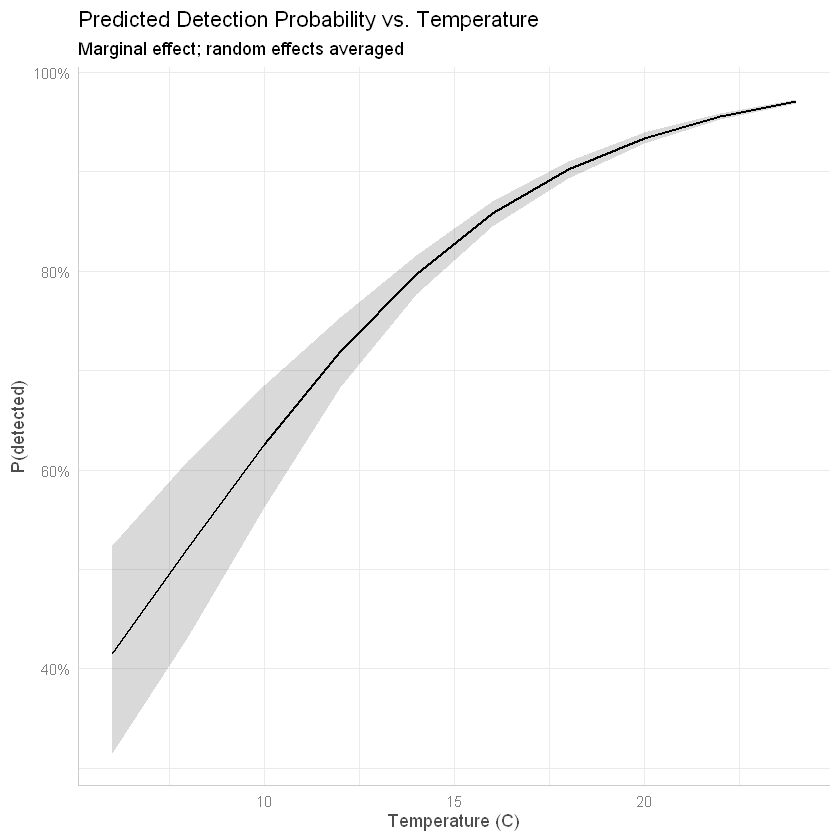

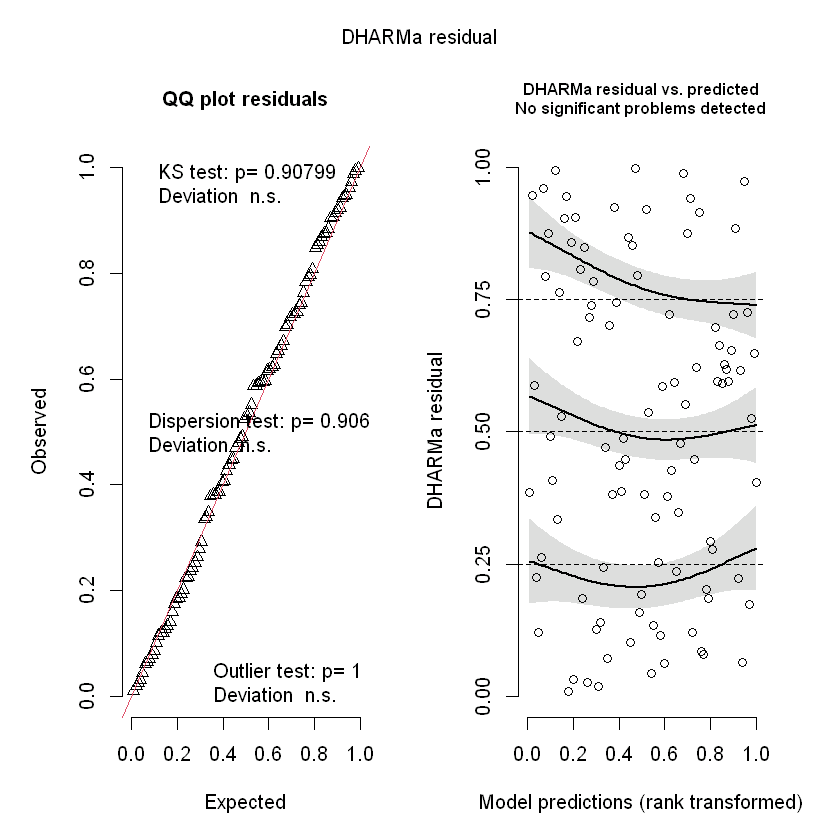


	DHARMa nonparametric dispersion test via sd of residuals fitted vs.
	simulated

data:  simulationOutput
dispersion = 1.0296, p-value = 0.906
alternative hypothesis: two.sided


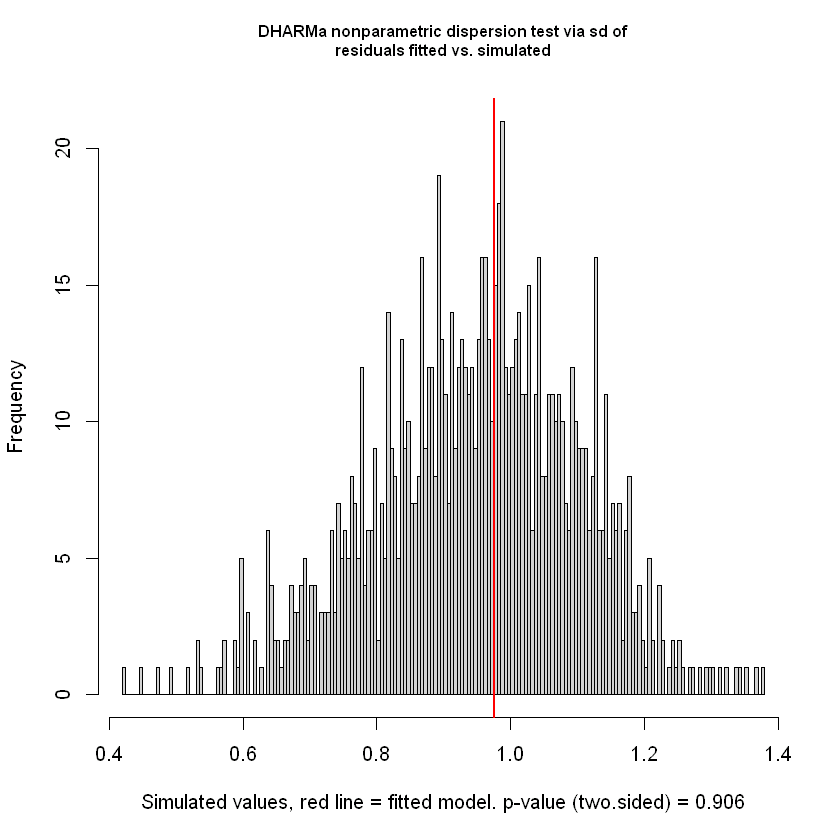


	DHARMa bootstrapped outlier test

data:  sim_bin
outliers at both margin(s) = 0, observations = 100, p-value = 1
alternative hypothesis: two.sided
 percent confidence interval:
 0 0
sample estimates:
outlier frequency (expected: 0 ) 
                               0 


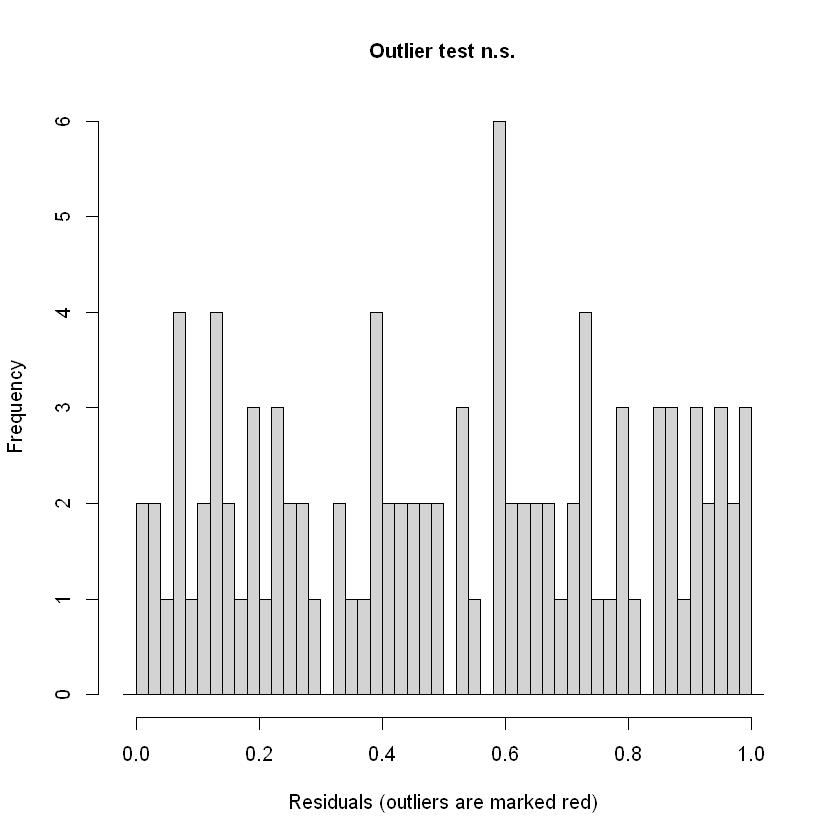

In [3]:
# ── Fit binomial GLMM ─────────────────────────────────────────────────────────
model_bin <- lme4::glmer(
  detected ~ temperature + (1 | site),
  data   = detection_data,
  family = binomial(link = "logit")
)
summary(model_bin)

# ── Odds ratios with 95% CIs ──────────────────────────────────────────────────
broom.mixed::tidy(model_bin, effects = "fixed",
                  exponentiate = TRUE, conf.int = TRUE) %>%
  mutate(across(where(is.numeric), ~ round(.x, 3)))

# ── Random effects variance ───────────────────────────────────────────────────
broom.mixed::tidy(model_bin, effects = "ran_pars") %>%
  mutate(across(where(is.numeric), ~ round(.x, 3)))

performance::r2(model_bin)

# ── Marginal effects plot ─────────────────────────────────────────────────────
ggeffects::ggpredict(model_bin, terms = "temperature") %>%
  plot() +
  labs(title = "Predicted Detection Probability vs. Temperature",
       subtitle = "Marginal effect; random effects averaged",
       x = "Temperature (C)", y = "P(detected)")

# ── DHARMa diagnostics ────────────────────────────────────────────────────────
sim_bin <- DHARMa::simulateResiduals(model_bin, n = 1000)
plot(sim_bin)
DHARMa::testDispersion(sim_bin)
DHARMa::testOutliers(sim_bin)

---

## Negative Binomial GLMM

**Question:** Does pH predict invertebrate abundance, accounting for site-level clustering and overdispersion?

Always start with Poisson and test for overdispersion — then upgrade to NB if needed.


	DHARMa nonparametric dispersion test via sd of residuals fitted vs.
	simulated

data:  simulationOutput
dispersion = 1.6484, p-value = 0.236
alternative hypothesis: two.sided


 Family: nbinom2  ( log )
Formula:          count ~ pH + (1 | site)
Data: count_data

      AIC       BIC    logLik -2*log(L)  df.resid 
    739.1     748.6    -365.5     731.1        76 

Random effects:

Conditional model:
 Groups Name        Variance Std.Dev.
 site   (Intercept) 0.2001   0.4473  
Number of obs: 80, groups:  site, 20

Dispersion parameter for nbinom2 family (): 2.29 

Conditional model:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)   0.7285     0.7781   0.936 0.349150    
pH            0.3797     0.1024   3.708 0.000209 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

effect,component,term,estimate,std.error,statistic,p.value,conf.low,conf.high
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
fixed,cond,(Intercept),2.072,1.612,0.936,0.349,0.451,9.521
fixed,cond,pH,1.462,0.150,3.708,0.000,1.196,1.787


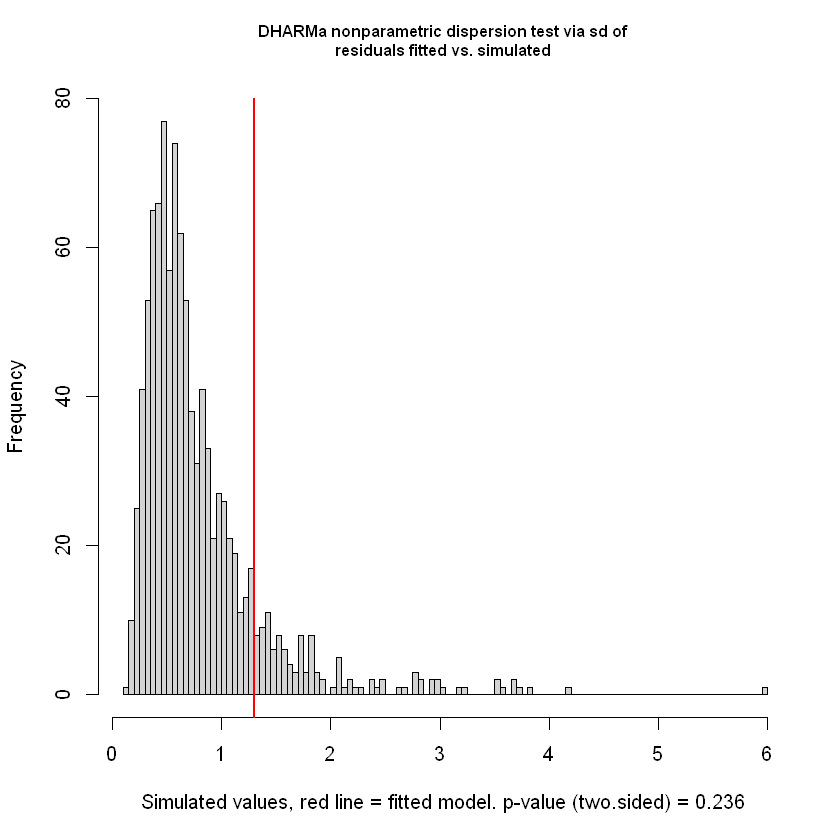

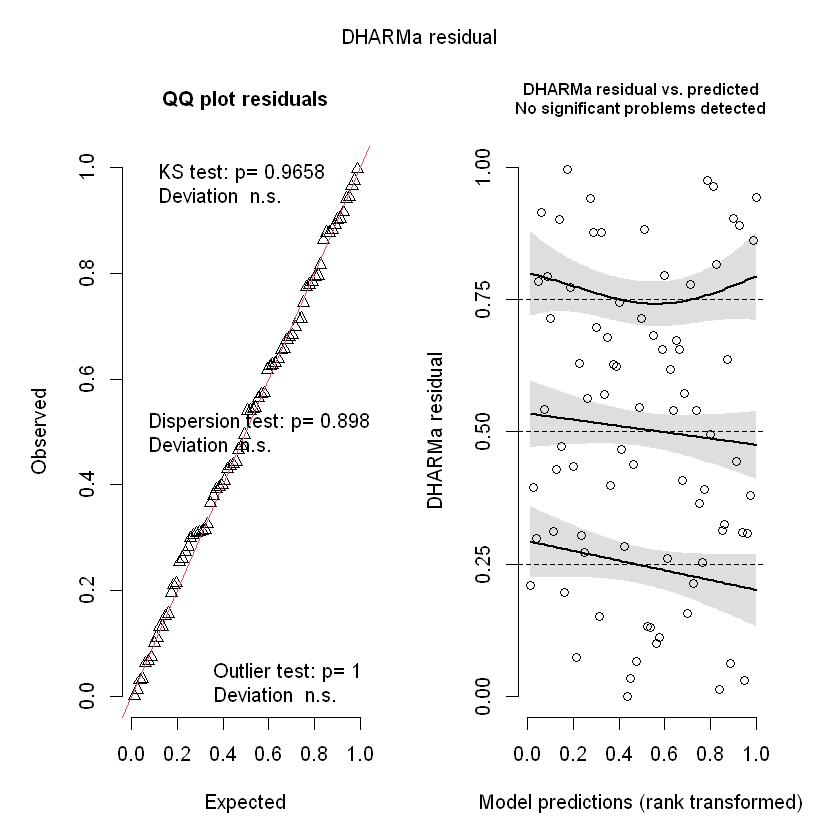


	DHARMa nonparametric dispersion test via sd of residuals fitted vs.
	simulated

data:  simulationOutput
dispersion = 0.92247, p-value = 0.898
alternative hypothesis: two.sided


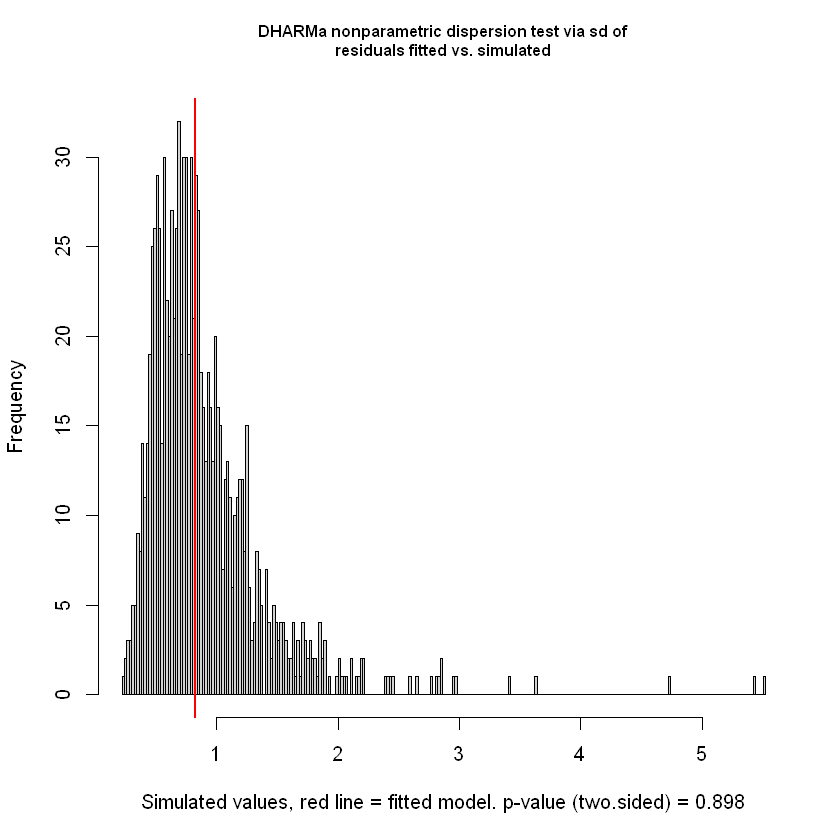


	DHARMa zero-inflation test via comparison to expected zeros with
	simulation under H0 = fitted model

data:  simulationOutput
ratioObsSim = 4.3478, p-value = 0.408
alternative hypothesis: two.sided


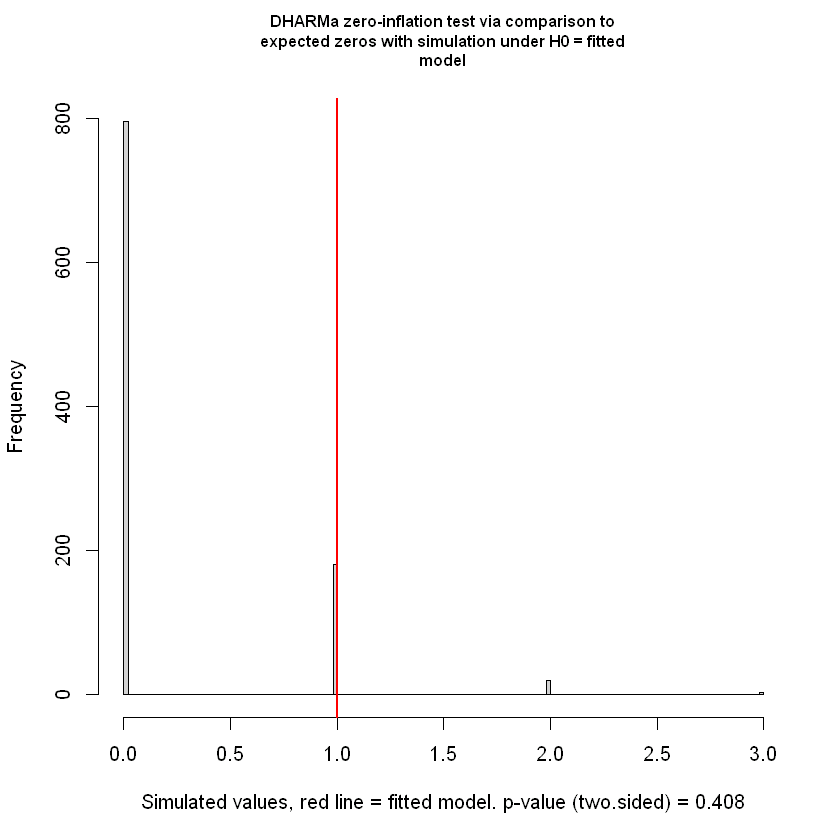

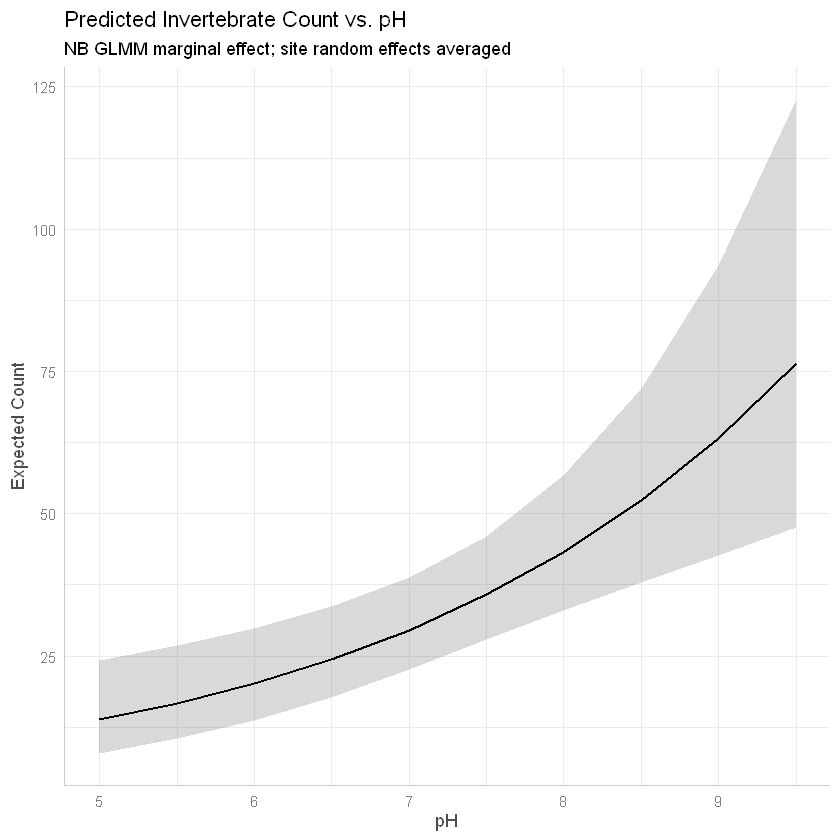

In [4]:
# ── Step 1: Fit Poisson GLMM and test overdispersion ─────────────────────────
model_pois <- lme4::glmer(
  count ~ pH + (1 | site),
  data = count_data, family = poisson
)
sim_pois <- DHARMa::simulateResiduals(model_pois, n = 1000)
DHARMa::testDispersion(sim_pois)
# p < 0.05 = overdispersion detected -> use negative binomial

# ── Step 2: Fit NB GLMM via glmmTMB (more stable than lme4::glmer.nb) ────────
model_nb <- glmmTMB::glmmTMB(
  count ~ pH + (1 | site),
  data   = count_data,
  family = glmmTMB::nbinom2   # NB2: variance = mu + mu^2/theta
)
summary(model_nb)

# ── IRRs with 95% CIs ─────────────────────────────────────────────────────────
broom.mixed::tidy(model_nb, effects = "fixed",
                  exponentiate = TRUE, conf.int = TRUE) %>%
  mutate(across(where(is.numeric), ~ round(.x, 3)))

# ── DHARMa diagnostics for NB GLMM ───────────────────────────────────────────
sim_nb <- DHARMa::simulateResiduals(model_nb, n = 1000)
plot(sim_nb)
DHARMa::testDispersion(sim_nb)       # should be non-significant now
DHARMa::testZeroInflation(sim_nb)    # check if excess zeros remain

# ── Marginal effects plot ─────────────────────────────────────────────────────
ggeffects::ggpredict(model_nb, terms = "pH") %>%
  plot() +
  labs(title = "Predicted Invertebrate Count vs. pH",
       subtitle = "NB GLMM marginal effect; site random effects averaged",
       x = "pH", y = "Expected Count")

---

## Zero-Inflated GLMM

If `testZeroInflation()` is significant after fitting NB, add a zero-inflation component via `glmmTMB`.

In [5]:
# ── Zero-inflated NB GLMM ─────────────────────────────────────────────────────
model_zinb <- glmmTMB::glmmTMB(
  count ~ pH + (1 | site),   # count model
  ziformula = ~1,             # zero-inflation: intercept only
                              # use ~pH if zero probability varies with pH
  data   = count_data,
  family = glmmTMB::nbinom2
)
summary(model_zinb)

AIC(model_nb, model_zinb)
# Lower AIC = better fit

 Family: nbinom2  ( log )
Formula:          count ~ pH + (1 | site)
Zero inflation:         ~1
Data: count_data

      AIC       BIC    logLik -2*log(L)  df.resid 
    740.3     752.2    -365.2     730.3        75 

Random effects:

Conditional model:
 Groups Name        Variance Std.Dev.
 site   (Intercept) 0.1889   0.4346  
Number of obs: 80, groups:  site, 20

Dispersion parameter for nbinom2 family (): 2.43 

Conditional model:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)   0.7424     0.7609   0.976 0.329247    
pH            0.3792     0.1001   3.787 0.000152 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Zero-inflation model:
            Estimate Std. Error z value Pr(>|z|)   
(Intercept)   -4.771      1.513  -3.153  0.00162 **
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

,df,AIC
,<dbl>,<dbl>
model_nb,4,739.0609
model_zinb,5,740.3003


---

## Reporting Results

In [6]:
cat("=== Binomial GLMM ===\n")
broom.mixed::tidy(model_bin, effects = "fixed",
                  exponentiate = TRUE, conf.int = TRUE) %>%
  rename(OR = estimate) %>%
  mutate(across(where(is.numeric), ~ round(.x, 3))) %>% print()

cat("\n=== Negative Binomial GLMM ===\n")
broom.mixed::tidy(model_nb, effects = "fixed",
                  exponentiate = TRUE, conf.int = TRUE) %>%
  rename(IRR = estimate) %>%
  mutate(across(where(is.numeric), ~ round(.x, 3))) %>% print()

# Reporting template:
# "[Predictor] significantly predicted [outcome] (OR/IRR = X.XX,
#  95% CI [X.XX, X.XX], p = .XXX). A [binomial/NB] GLMM with a
#  random intercept for [grouping variable] accounted for the
#  [repeated-measures/clustered] data structure (random effect SD = X.XX).
#  DHARMa residual diagnostics indicated no systematic model misfit."

=== Binomial GLMM ===
# A tibble: 2 × 8
  effect term           OR std.error statistic p.value conf.low conf.high
  <chr>  <chr>       <dbl>     <dbl>     <dbl>   <dbl>    <dbl>     <dbl>
1 fixed  (Intercept) 0.197     0.303     -1.06   0.291     0.01      4.01
2 fixed  temperature 1.24      0.131      2.03   0.043     1.01      1.52

=== Negative Binomial GLMM ===
# A tibble: 2 × 9
  effect component term       IRR std.error statistic p.value conf.low conf.high
  <chr>  <chr>     <chr>    <dbl>     <dbl>     <dbl>   <dbl>    <dbl>     <dbl>
1 fixed  cond      (Interc…  2.07      1.61     0.936   0.349    0.451      9.52
2 fixed  cond      pH        1.46      0.15     3.71    0        1.20       1.79


---

## Common Pitfalls

**1. Using standard GLM on clustered data**  
Ignoring the grouping structure underestimates standard errors and inflates type I error. Always include a random effect for the grouping variable.

**2. Skipping DHARMa diagnostics**  
Standard residual plots are misleading for GLMMs. DHARMa simulation-based residuals are the correct and necessary diagnostic tool — use them for every GLMM.

**3. Defaulting to Poisson without testing for overdispersion**  
Poisson GLMMs are almost always overdispersed in real ecological and industry data. Always test with DHARMa's `testDispersion()` and upgrade to NB if needed.

**4. Using `lme4::glmer.nb()` for NB models**  
`glmer.nb()` is less numerically stable than `glmmTMB`. Use `glmmTMB` for NB, Gamma, zero-inflated, and other non-standard distributions.

**5. Ignoring convergence warnings**  
Convergence failures from `glmer()` are common. Try `control = glmerControl(optimizer = "bobyqa")` or simplify the random effects structure before trusting results.

**6. Reporting only marginal effects without noting random effects**  
Always report the random effect variance alongside fixed effects — it tells readers how much group-to-group variation exists, which is scientifically informative.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*